# Men's Model

This notebook makes the machine learning model. Remember to uncomment the last cell if you would like to save the model. 

### Data Setup

In [1]:
import pandas as pd

pd.set_option('display.max_columns', 100)

df_mod = pd.read_parquet(r'..\data\preprocessed\mens_model_data\model_data.parquet')

df_mod

,Season,Round,Result,Team A ID,Team A,Team B ID,Team B,Head to Head,Common Opps,Past Year Tournament Result,Past 4 Years Tournament Results,ADJ OE,ADJ DE,ADJ EM,BARTHAG,WIN%,EFG,EFG D.,FT RATE,FT RATE D,TOV%,TOV% D,O REB%,OP OREB%,RAW T,2P % D.,3P % D.,BLK %,BLKED %,AST %,OP AST %,3P RATE,3P RATE D,ADJ. T,EFF. HGT.,EXP.,TALENT,FT%,ELITE SOS,Past Year BARTHAG,Past Year ADJ EM,Past 4 Years BARTHAG,Past 4 Years ADJ EM,Rating,Efficiency Margin,Adjusted Offense,Adjusted Defense,Adjusted Tempo,Starters,Mu,OS Rating,Implied Champion Probability,Team A ADJ OE Team B ADJ DE,Team B ADJ OE Team A ADJ DE,Team A Offense Team B Defense,Team B Offense Team A Defense,Team A BARTHAG,Team B BARTHAG
0,2012,1,1,1124,Baylor,1355,S Dakota St,NaN,NaN,0.0,1.250000,2.7,-7.1,9.8,0.143,0.006629,-1.2,-2.7,-3.4,2.2,5.0,2.1,7.1,4.7,1.2,-5.0,1.5,7.4,0.9,2.9,6.0,-5.2,1.5,0.4,2.572,0.092,54.372,2.2,18.008,0.070,2.416,0.42825,20.00450,2.236931,0.059841,0.002742,-0.057099,0.798256,0.117964,6.155373,6.307358,NaN,215.1,205.3,2.102476,2.042635,0.910,0.767
1,2012,1,1,1160,Colorado,1424,UNLV,NaN,-0.354522,-1.0,-1.000000,-5.1,1.9,-7.0,-0.114,-0.093750,-3.9,0.9,7.2,-0.9,-0.3,-2.3,-3.3,-1.7,-3.7,1.4,-0.2,-3.6,3.9,-15.6,-1.2,-6.9,1.5,-4.0,-0.808,-0.550,-17.999,0.3,-1.350,-0.085,-4.570,-0.16850,-8.01825,-0.941257,-0.080215,-0.058851,0.021364,-3.732952,-0.226425,-5.594902,-5.063750,-0.006579,196.5,203.5,1.940861,2.021076,0.761,0.875
2,2012,1,1,1211,Gonzaga,1452,West Virginia,NaN,0.812990,0.0,-0.750000,-0.3,-1.2,0.9,0.014,0.212702,4.7,-2.8,8.9,-4.7,0.6,-0.7,-6.4,-2.5,1.8,-3.7,-0.5,2.0,-1.4,-1.7,-2.5,2.0,3.4,0.7,0.694,-0.074,-24.821,4.4,-10.613,-0.028,-3.011,-0.02675,-2.83100,0.282496,0.032107,0.004526,-0.027581,0.797444,0.164332,6.373943,5.266265,0.001314,206.1,205.2,2.036170,2.004063,0.862,0.848
3,2012,1,1,1231,Indiana,1308,New Mexico St,NaN,NaN,0.0,0.000000,13.0,-0.9,13.9,0.190,0.030303,4.0,-0.1,-6.2,1.0,-1.6,-0.1,-5.2,1.5,-3.8,-2.2,2.9,-1.4,2.6,-0.7,-8.4,3.1,0.1,-3.3,0.873,-0.372,59.973,9.8,17.567,0.189,7.508,0.00800,1.45825,1.413612,0.097072,0.094070,-0.003003,-3.031662,0.115812,6.609197,6.794695,NaN,216.5,202.6,2.115323,2.018251,0.918,0.728
4,2012,1,1,1235,Iowa St,1163,Connecticut,NaN,1.186719,-7.0,-3.250000,0.9,1.0,-0.1,-0.003,0.081439,2.7,3.9,4.3,0.8,-0.8,0.7,-4.6,-8.3,3.4,9.4,-4.5,-10.7,3.1,5.1,-0.6,13.0,-3.5,3.0,-1.707,1.082,-3.734,1.8,-2.296,-0.193,-13.367,-0.20000,-13.53850,0.177334,0.010723,0.021480,0.010757,2.394492,-0.035981,3.194011,3.145467,-0.009950,205.5,205.6,2.036885,2.026162,0.855,0.858
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1505,2024,4,-1,1181,Duke,1301,NC State,0.092813,0.427451,1.0,2.000000,7.1,-3.8,10.9,0.126,0.138889,4.5,-1.5,1.3,-4.3,0.6,-1.0,3.2,-3.4,-1.1,-0.4,-2.3,0.5,4.1,7.7,2.3,3.9,0.2,-1.0,1.687,-1.262,43.185,-1.2,-1.832,0.080,5.906,0.13675,10.16675,0.087462,0.121428,0.071851,-0.049577,-0.986364,0.151976,4.388026,3.498631,0.027283,221.4,210.5,2.210975,2.089547,0.926,0.800
1506,2024,4,-1,1397,Tennessee,1345,Purdue,-0.571735,0.206760,2.0,0.333333,-10.7,-3.2,-7.5,-0.028,-0.128788,-4.5,-2.3,-8.5,12.8,-1.9,4.9,-5.0,3.9,1.6,-3.8,0.0,4.0,2.0,-3.3,-5.6,6.3,4.2,1.6,-3.043,0.405,2.815,2.8,-1.438,0.007,-0.478,-0.01675,-1.74175,-0.291782,-0.031208,-0.077513,-0.046305,1.403171,-0.133075,-4.770856,-3.938319,-0.070833,209.7,217.2,2.106880,2.138088,0.938,0.966
1507,2024,5,-1,1104,Alabama,1163,Connecticut,NaN,-0.512516,-4.0,-0.666667,-1.2,7.3,-8.5,-0.048,-0.255515,-0.8,4.8,1.9,7.1,1.1,-0.6,-1.6,3.1,8.0,7.4,0.0,-4.0,4.2,-12.2,-0.9,5.9,3.5,7.9,0.817,0.392,-30.485,4.2,2.281,-0.009,-3.217,-0.00150,-0.50050,-0.455486,-0.071231,-0.004177,0.067054,7.544173,-0.265038,-10.958853,-10.211179,-0.197832,219.7,228.2,2.174375,2.245606,0.921,0.969
1508,2024,5,-1,1301,NC State,1345,Purdue,NaN,-1.260545,0.0,-1.333333,-12.5,6.4,-18.9,-0.166,-0.267677,-5.3,2.8,-10.3,8.9,-2.8,3.9,-8.8,

Remove features that don't seem to be helping model

In [ ]:
df_mod.drop(
    columns=[
        # 'Team A ADJ OE Team B ADJ DE',
        # 'Team B ADJ OE Team A ADJ DE',
        '3P RATE D',
        # 'Past Year ADJ EM',
        'EFF. HGT.',
        'EFG',
        'WIN%',
        # 'Efficiency Margin',
        'EXP.',
        'FT RATE D',
        'Team A Offense Team B Defense',
        'Team B Offense Team A Defense',
        # 'Past Year Tournament Result',
        'Round',
        'ADJ. T',
        'Head to Head',
        'EFG D.',

        # 'Team A BARTHAG',
        # 'Team B BARTHAG',

        # 'Past Year Tournament Result',

        # 'TOV%',
        # 'TOV% D',

        'OP OREB%',

        # 'Mu',
    ],
    inplace=True,
)

Get monotonic constraints

In [3]:
correlations = df_mod.corr(numeric_only=True)['Result']

correlations.round(2).sort_values()

Team B ADJ OE Team A ADJ DE       -0.39
ADJ DE                            -0.38
Adjusted Defense                  -0.37
Team B BARTHAG                    -0.36
2P % D.                           -0.19
TOV%                              -0.17
3P % D.                           -0.12
BLKED %                           -0.11
FT RATE                           -0.11
OP AST %                          -0.04
Team A ID                         -0.03
RAW T                             -0.01
Season                             0.00
Adjusted Tempo                     0.00
3P RATE                           -0.00
Team B ID                          0.03
TOV% D                             0.05
FT%                                0.07
AST %                              0.09
BLK %                              0.17
O REB%                             0.20
Common Opps                        0.30
Past Year Tournament Result        0.32
Team A BARTHAG                     0.36
Implied Champion Probability       0.37


In [4]:
# df_mod = df_mod.loc[:, ['Season', 'Team A ID', 'Team A', 'Team B ID', 'Team B'] + list(correlations.loc[correlations.abs() >= 0.00].index)]

# df_mod

In [5]:
correlations = df_mod.corr(numeric_only=True)['Result']

correlations.round(2).sort_values()

Team B ADJ OE Team A ADJ DE       -0.39
ADJ DE                            -0.38
Adjusted Defense                  -0.37
Team B BARTHAG                    -0.36
2P % D.                           -0.19
TOV%                              -0.17
3P % D.                           -0.12
BLKED %                           -0.11
FT RATE                           -0.11
OP AST %                          -0.04
Team A ID                         -0.03
RAW T                             -0.01
Season                             0.00
Adjusted Tempo                     0.00
3P RATE                           -0.00
Team B ID                          0.03
TOV% D                             0.05
FT%                                0.07
AST %                              0.09
BLK %                              0.17
O REB%                             0.20
Common Opps                        0.30
Past Year Tournament Result        0.32
Team A BARTHAG                     0.36
Implied Champion Probability       0.37


In [6]:
correlations_threshold = 0.10

correlations.loc[correlations.abs() < correlations_threshold].round(2)

Season            0.00
Team A ID        -0.03
Team B ID         0.03
TOV% D            0.05
RAW T            -0.01
AST %             0.09
OP AST %         -0.04
3P RATE          -0.00
FT%               0.07
Adjusted Tempo    0.00
Name: Result, dtype: float64

In [7]:
monotone_constraints_dict = dict(zip(
    df_mod.drop(columns=['Team A', 'Team B']).columns[correlations > correlations_threshold], 
    [1 for _ in range((correlations > correlations_threshold).sum())]
))

monotone_constraints_dict.update(dict(zip(
    df_mod.drop(columns=['Team A', 'Team B']).columns[correlations < -correlations_threshold], 
    [-1 for _ in range((correlations < -correlations_threshold).sum())]
)))

del monotone_constraints_dict['Result']

monotone_constraints_dict

{'Common Opps': 1,
 'Past Year Tournament Result': 1,
 'Past 4 Years Tournament Results': 1,
 'ADJ OE': 1,
 'ADJ EM': 1,
 'BARTHAG': 1,
 'O REB%': 1,
 'BLK %': 1,
 'TALENT': 1,
 'ELITE SOS': 1,
 'Past Year BARTHAG': 1,
 'Past Year ADJ EM': 1,
 'Past 4 Years BARTHAG': 1,
 'Past 4 Years ADJ EM': 1,
 'Rating': 1,
 'Efficiency Margin': 1,
 'Adjusted Offense': 1,
 'Starters': 1,
 'Mu': 1,
 'OS Rating': 1,
 'Implied Champion Probability': 1,
 'Team A ADJ OE Team B ADJ DE': 1,
 'Team A BARTHAG': 1,
 'ADJ DE': -1,
 'FT RATE': -1,
 'TOV%': -1,
 '2P % D.': -1,
 '3P % D.': -1,
 'BLKED %': -1,
 'Adjusted Defense': -1,
 'Team B ADJ OE Team A ADJ DE': -1,
 'Team B BARTHAG': -1}

Create train-val-test folds

In [8]:
from sklearn.model_selection import GroupKFold
import numpy as np

np.random.seed(22)

gkf = GroupKFold(n_splits=3)

cv_data = []
for train_val_index, test_index in gkf.split(df_mod.index, groups=df_mod['Season']):
    df_train_val_iter = df_mod.loc[train_val_index, :]
    df_test_iter = df_mod.loc[test_index, :]

    val_seasons = np.random.choice(df_train_val_iter['Season'].unique(), size=3, replace=False)

    X_train_iter = (
        df_train_val_iter
        .loc[~df_train_val_iter['Season'].isin(val_seasons), :]
        .drop(columns=['Season', 'Result', 'Team A ID', 'Team A', 'Team B ID', 'Team B'])
    )
    X_val_iter = (
        df_train_val_iter
        .loc[df_train_val_iter['Season'].isin(val_seasons), :]
        .drop(columns=['Season', 'Result', 'Team A ID', 'Team A', 'Team B ID', 'Team B'])
    )
    X_test_iter = (
        df_test_iter
        .drop(columns=['Season', 'Result', 'Team A ID', 'Team A', 'Team B ID', 'Team B'])
    )

    y_train_iter = (
        df_train_val_iter
        .loc[~df_train_val_iter['Season'].isin(val_seasons), 'Result']
    )
    y_val_iter = (
        df_train_val_iter
        .loc[df_train_val_iter['Season'].isin(val_seasons), 'Result']
    )
    y_test_iter = (
        df_test_iter['Result']
    )

    cv_data.append((
        X_train_iter, 
        X_val_iter, 
        X_test_iter, 
        y_train_iter, 
        y_val_iter, 
        y_test_iter,
        df_test_iter,
    ))

len(cv_data)

3

In [9]:
monotone_constraints = [monotone_constraints_dict.get(c, 0) for c in X_train_iter.columns]

monotone_constraints

[1,
 1,
 1,
 1,
 -1,
 1,
 1,
 -1,
 -1,
 0,
 1,
 0,
 -1,
 -1,
 1,
 -1,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 -1,
 0,
 1,
 1,
 1,
 1,
 1,
 -1,
 1,
 -1]

In [10]:
from sklearn.metrics import brier_score_loss  # log_loss
from lightgbm import LGBMClassifier
import optuna
import numpy as np

testing_data = []
def objective(trial, cv_data=cv_data):
    # model tuning
    params = {
        'random_state': 22,
        # 'metric': 'binary_logloss',
        'metric': 'rmse',  # brier score
        'verbosity': -1,
        'n_estimators': 1_000,
        'early_stopping_round': 25,
        'monotone_constraints': monotone_constraints,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.20),
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0),
        'max_depth': trial.suggest_int('max_depth', 1, 32),
        'num_leaves': trial.suggest_int('num_leaves', 2, 2**8),
        'feature_fraction': trial.suggest_float('feature_fraction', 1e-8, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 1, 100),
    }
    mod = LGBMClassifier(**params)

    # cross validation
    y_actuals = []
    y_preds = []
    trial_testing_data = []
    for X_train, X_val, X_test, y_train, y_val, y_test, df_test in cv_data:
        y_actuals.append(y_test)

        mod.fit(
            X_train, 
            y_train, 
            eval_set=(X_val, y_val),
        )

        predictions = mod.predict_proba(X_test)[:, 1]
        y_preds.append(predictions)

        df_test['Prediction'] = predictions
        trial_testing_data.append(df_test)

    testing_data.append(trial_testing_data)
    # return log_loss(np.hstack(y_actuals), np.hstack(y_preds))
    return brier_score_loss(np.hstack(y_actuals), np.hstack(y_preds))

study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=22, n_startup_trials=100, multivariate=True))
study.optimize(objective, n_trials=1_000, show_progress_bar=True)

study.best_params

c:\Users\mhugh\anaconda3\envs\clean2\lib\site-packages\optuna\_experimental.py:30: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(
[I 2025-03-15 21:28:36,058] A new study created in memory with name: no-name-8382f476-0511-4909-99a0-79704918bdc9


  0%|          | 0/1000 [00:00<?, ?it/s]

[I 2025-03-15 21:28:36,493] Trial 0 finished with value: 0.18738320962988114 and parameters: {'learning_rate': 0.0496075020981801, 'lambda_l1': 4.816810622816848, 'lambda_l2': 4.205380358938367, 'max_depth': 28, 'num_leaves': 45, 'feature_fraction': 0.33886396721506074, 'min_child_samples': 28}. Best is trial 0 with value: 0.18738320962988114.
[I 2025-03-15 21:28:36,658] Trial 1 finished with value: 0.18959074112624252 and parameters: {'learning_rate': 0.14129785658542326, 'lambda_l1': 2.204045174173211, 'lambda_l2': 8.119509207267358, 'max_depth': 1, 'num_leaves': 145, 'feature_fraction': 0.8137261892779346, 'min_child_samples': 75}. Best is trial 0 with value: 0.18738320962988114.
[I 2025-03-15 21:28:36,986] Trial 2 finished with value: 0.18756172935186946 and parameters: {'learning_rate': 0.04593115749950678, 'lambda_l1': 0.061408673399573614, 'lambda_l2': 7.720438716724923, 'max_depth': 31, 'num_leaves': 180, 'feature_fraction': 0.29757827388926783, 'min_child_samples': 77}. Best i

{'learning_rate': 0.08417263027166265,
 'lambda_l1': 1.2272140531521787,
 'lambda_l2': 0.41222610005136445,
 'max_depth': 5,
 'num_leaves': 134,
 'feature_fraction': 0.18250666863795148,
 'min_child_samples': 13}

In [11]:
# optuna.importance.get_param_importances(study)

### Prediction Evaluation

In [12]:
df_test = pd.concat(testing_data[study.best_trial.number], ignore_index=True)

df_test

,Season,Result,Team A ID,Team A,Team B ID,Team B,Common Opps,Past Year Tournament Result,Past 4 Years Tournament Results,ADJ OE,ADJ DE,ADJ EM,BARTHAG,FT RATE,TOV%,TOV% D,O REB%,RAW T,2P % D.,3P % D.,BLK %,BLKED %,AST %,OP AST %,3P RATE,TALENT,FT%,ELITE SOS,Past Year BARTHAG,Past Year ADJ EM,Past 4 Years BARTHAG,Past 4 Years ADJ EM,Rating,Efficiency Margin,Adjusted Offense,Adjusted Defense,Adjusted Tempo,Starters,Mu,OS Rating,Implied Champion Probability,Team A ADJ OE Team B ADJ DE,Team B ADJ OE Team A ADJ DE,Team A BARTHAG,Team B BARTHAG,Prediction
0,2013,1,1112,Arizona,1125,Belmont,0.137125,-1.0,1.250000,4.1,-2.5,6.6,0.080,5.0,-0.3,-4.5,5.0,-1.2,-2.2,3.1,2.2,-1.7,-1.9,-4.5,-1.6,76.885,1.3,11.218,-0.089,-6.103,0.07300,3.72925,0.313128,0.016403,0.002462,-0.013940,-0.112520,-0.076628,0.999295,1.609308,0.015624,207.9,201.3,0.910,0.830,0.697755
1,2013,1,1139,Butler,1137,Bucknell,-0.511020,0.0,3.000000,3.8,0.5,3.3,0.048,1.5,5.4,3.0,6.6,2.1,4.6,2.2,-4.4,3.4,-2.0,-0.4,11.4,58.645,-5.7,16.274,-0.017,-1.022,0.35100,15.70000,0.804659,-0.003113,0.016462,0.019575,0.868001,-0.009628,0.871637,2.464416,0.008362,202.6,199.3,0.856,0.808,0.733959
2,2013,1,1143,California,1424,UNLV,0.580501,0.0,0.250000,0.0,4.7,-4.7,-0.079,-5.2,-1.5,-2.0,-0.7,-2.5,-0.6,2.3,-3.2,0.6,-8.7,1.3,-11.3,-12.256,1.9,3.717,-0.008,-0.382,-0.00300,0.84250,-0.300439,-0.045236,0.006481,0.051718,-3.183278,-0.155030,-4.380436,-4.369119,-0.008303,194.6,199.3,0.798,0.877,0.393951
3,2013,1,1161,Colorado St,1281,Missouri,NaN,0.0,-1.750000,2.6,2.2,0.4,0.000,8.2,-2.6,-0.6,2.3,-4.2,2.6,1.0,-3.6,-0.1,0.4,-2.5,-4.0,-26.760,-3.0,-2.574,-0.217,-17.332,-0.28700,-17.06575,-0.041620,-0.008243,0.021744,0.029987,-2.885874,0.026373,1.235717,1.058638,-0.004614,210.7,210.3,0.877,0.877,0.386401
4,2013,1,1211,Gonzaga,1380,Southern Univ,0.228265,2.0,2.250000,23.3,-7.2,30.5,0.502,0.7,0.3,0.6,10.7,-0.2,1.7,2.2,-2.3,-0.7,6.8,5.3,-3.3,22.895,2.4,14.129,0.765,35.453,0.82300,43.06125,3.056608,0.258906,0.193181,-0.065725,-0.016493,0.470761,25.905088,25.929424,NaN,216.9,186.4,0.961,0.459,0.896891
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1505,2022,-1,1274,Miami FL,1242,Kansas,-0.269654,-2.0,-2.666667,-5.9,7.7,-13.6,-0.138,-3.9,-3.6,1.9,-10.0,-2.0,6.0,5.1,-2.0,0.8,-3.1,9.1,2.1,-9.566,1.9,-9.139,-0.298,-14.326,-0.20000,-13.64625,-0.971177,-0.126777,-0.050383,0.076394,-1.552321,-0.174656,-10.317116,-10.863963,-0.096016,207.2,220.8,0.813,0.951,0.154220
1506,2022,-1,1389,St Peter's,1314,North Carolina,NaN,-1.0,-2.000000,-15.2,-1.8,-13.4,-0.262,7.9,4.3,6.8,1.1,-3.2,-4.3,-5.5,4.9,4.7,-2.0,3.6,-7.1,-87.253,-8.7,-17.347,-0.514,-21.106,-0.54100,-25.66650,-1.533325,-0.085932,-0.115164,-0.029231,-4.146975,-0.107616,-7.564626,-8.252757,-0.007603,193.5,206.9,0.604,0.866,0.341228
1507,2022,-1,1437,Villanova,1242,Kansas,-0.591474,1.0,1.000000,-3.1,0.1,-3.2,-0.017,-2.3,-2.3,0.4,-2.5,-5.3,0.3,0.9,-3.4,3.1,-4.9,2.5,12.2,-8.927,9.9,-4.584,0.033,4.488,-0.01375,0.06275,-0.084881,-0.012273,-0.016637,-0.004364,-5.693499,-0.025600,-0.883534,-1.093154,-0.047368,210.0,213.2,0.934,0.951,0.369323
1508,2022,-1,1181,Duke,1314,North Carolina,0.402357,-1.0,0.666667,7.6,-1.5,9.1,0.077,-1.0,-1.6,2.0,1.5,-1.9,-1.4,-3.5,3.4,-0.4,3.0,3.8,-0.8,4.068,-4.3,-1.297,0.012,1.757,0.05875,5.52925,0.479628,0.079144,0.063898,-0.015246,-2.343528,0.112170,4.309934,3.326716,0.058730,216.3,207.2,0.943,0.866,0.763708


In [13]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, threshold = roc_curve(df_test['Result'], df_test['Prediction'])

auc_value = auc(fpr, tpr)

auc_value

0.7941458707951405

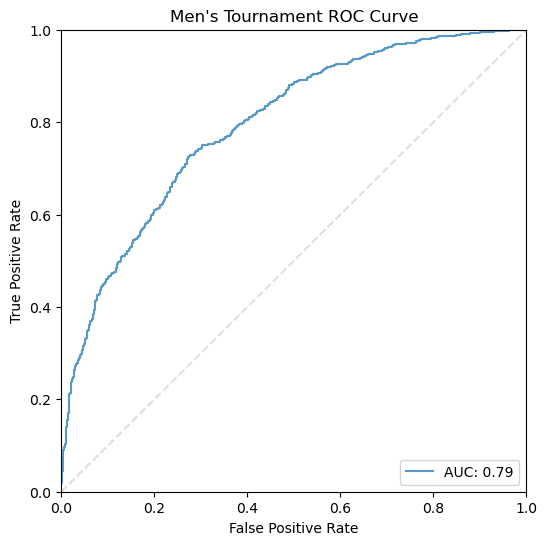

In [14]:
import matplotlib.pyplot as plt

# plt.figure(figsize=(3.5, 3.5), dpi=400)
plt.figure(figsize=(6, 6), dpi=100)

plt.plot(fpr, tpr, label = f"AUC: {auc_value:.2f}", alpha=0.75)
plt.axline([0, 0], [1, 1], color='gray', linestyle='--', alpha=0.25)

plt.title("Men's Tournament ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend(loc='lower right')

plt.xlim(0.0, 1.0)
plt.ylim(0.0, 1.0)

plt.show()

In [15]:
from sklearn.metrics import log_loss

print('Out-of-sample log losses by season')
for season in sorted(df_test['Season'].unique()):
    print(f"{season}: {log_loss(df_test.loc[df_test['Season'] == season, 'Result'], df_test.loc[df_test['Season'] == season, 'Prediction']):.4f}")

Out-of-sample log losses by season
2012: 0.5023
2013: 0.5385
2014: 0.5800
2015: 0.4768
2016: 0.5113
2017: 0.5009
2018: 0.5713
2019: 0.4712
2021: 0.6004
2022: 0.6122
2023: 0.6314
2024: 0.5661


In [16]:
print('Out-of-sample Brier scores by season')
for season in sorted(df_test['Season'].unique()):
    print(f"{season}: {brier_score_loss(df_test.loc[df_test['Season'] == season, 'Result'], df_test.loc[df_test['Season'] == season, 'Prediction']):.4f}")

Out-of-sample Brier scores by season
2012: 0.1660
2013: 0.1826
2014: 0.1994
2015: 0.1553
2016: 0.1689
2017: 0.1667
2018: 0.1947
2019: 0.1593
2021: 0.2082
2022: 0.2115
2023: 0.2152
2024: 0.1941


In [17]:
# df_test.loc[(df_test['Season'] == 2023) & (df_test['Team A'] == 'Connecticut'), 'Prediction'] = 0.9999
# df_test.loc[(df_test['Season'] == 2023) & (df_test['Team B'] == 'Connecticut'), 'Prediction'] = 0.0001

# print('Out-of-sample Brier scores by season')
# for season in sorted(df_test['Season'].unique()):
#     print(f"{season}: {brier_score_loss(df_test.loc[df_test['Season'] == season, 'Result'], df_test.loc[df_test['Season'] == season, 'Prediction']):.4f}")

In [18]:
# df_test.loc[(df_test['Season'] == 2021) & (df_test['Team A'] == 'Baylor'), 'Prediction'] = 0.9999
# df_test.loc[(df_test['Season'] == 2021) & (df_test['Team B'] == 'Baylor'), 'Prediction'] = 0.0001

# print('Out-of-sample log losses by season')
# for season in sorted(df_test['Season'].unique()):
#     print(f"{season}: {log_loss(df_test.loc[df_test['Season'] == season, 'Result'], df_test.loc[df_test['Season'] == season, 'Prediction']):.4f}")

In [19]:
def get_bin_sample_sizes(y_prob, n_bins):
    y_prob = pd.Series(y_prob)
    bins = pd.cut(
        y_prob,
        np.linspace(0.0, 1.0, n_bins + 1),
    )

    return np.array([y_prob.loc[(y_prob > bin.left) & (y_prob <= bin.right)].shape[0] for bin in sorted(bins.unique())])

bin_sample_sizes = get_bin_sample_sizes(np.hstack(df_test['Prediction']), 20)

bin_sample_sizes

array([ 11,  58, 100,  89,  84,  81,  80,  85,  86,  78,  90,  93,  68,
        81,  78,  97,  83,  95,  64,   9])

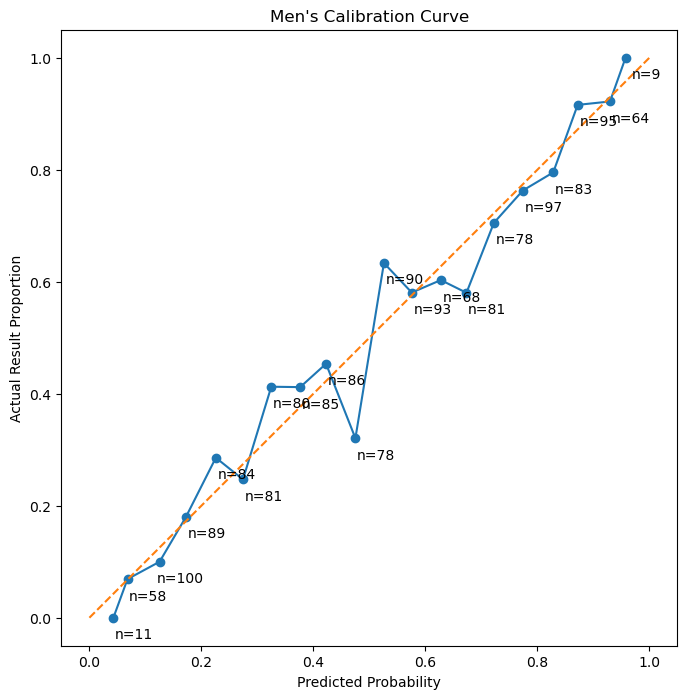

In [20]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(
    df_test['Result'], 
    df_test['Prediction'], 
    n_bins=20,
)

fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(prob_pred, prob_true, marker='o')
ax.plot([0, 1], [0, 1], linestyle='dashed')

for i, (xi, yi, ni) in enumerate(zip(prob_pred, prob_true, bin_sample_sizes)):
    plt.annotate(f'n={ni}', (xi, yi), textcoords='offset points', xytext=(15, -15), ha='center')

ax.set_aspect('equal')

plt.title("Men's Calibration Curve")
plt.xlabel('Predicted Probability')
plt.ylabel('Actual Result Proportion')

plt.show()

In [21]:
df_test['Prediction'].describe()

count    1510.000000
mean        0.499352
std         0.261052
min         0.032025
25%         0.268471
50%         0.504000
75%         0.727204
max         0.967020
Name: Prediction, dtype: float64

In [22]:
# convert results to 0/1 instead of -1/1 for this analysis
((df_test['Result'] + 1)/2 - df_test['Prediction']).abs().describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).round(4)

count    1510.0000
mean        0.3670
std         0.2246
min         0.0320
1%          0.0479
5%          0.0669
25%         0.1692
50%         0.3272
75%         0.5268
95%         0.7826
99%         0.8779
max         0.9476
dtype: float64

In [23]:
df_test.loc[((df_test['Result'] + 1)/2 - df_test['Prediction']).abs() > 0.90, :]

,Season,Result,Team A ID,Team A,Team B ID,Team B,Common Opps,Past Year Tournament Result,Past 4 Years Tournament Results,ADJ OE,ADJ DE,ADJ EM,BARTHAG,FT RATE,TOV%,TOV% D,O REB%,RAW T,2P % D.,3P % D.,BLK %,BLKED %,AST %,OP AST %,3P RATE,TALENT,FT%,ELITE SOS,Past Year BARTHAG,Past Year ADJ EM,Past 4 Years BARTHAG,Past 4 Years ADJ EM,Rating,Efficiency Margin,Adjusted Offense,Adjusted Defense,Adjusted Tempo,Starters,Mu,OS Rating,Implied Champion Probability,Team A ADJ OE Team B ADJ DE,Team B ADJ OE Team A ADJ DE,Team A BARTHAG,Team B BARTHAG,Prediction
87,2016,1,1372,SF Austin,1452,West Virginia,-1.519897,-2.0,-0.250000,-6.9,7.4,-14.3,-0.172,-12.2,-1.4,0.4,-8.4,-1.7,1.3,0.0,1.2,-1.9,10.2,1.7,5.8,-46.019,7.4,-25.375,-0.067,-3.886,-0.0595,-3.317250,-1.739148,-0.083774,-0.036663,0.047111,-1.871159,-0.056291,-5.826062,-7.643639,-0.039852,198.7,213.0,0.772,0.944,0.096237
659,2018,1,1420,UMBC,1438,Virginia,NaN,-2.0,-2.750000,-12.7,20.5,-33.2,-0.553,5.2,2.8,-0.3,-1.0,8.6,8.4,5.6,-4.9,1.1,3.2,6.6,9.3,-60.776,-10.7,-18.895,-0.508,-27.053,-0.7645,-41.574500,-3.243479,-0.308918,-0.120457,0.188461,8.440729,-0.503923,-22.685753,-22.128237,-0.138789,187.5,220.7,0.418,0.971,0.053640
712,2023,1,1192,F Dickinson,1345,Purdue,NaN,-3.0,-2.333333,-13.5,23.8,-37.3,-0.711,-8.4,-0.6,6.0,-7.2,5.1,8.7,4.8,-4.1,1.2,-9.3,5.0,-0.6,-58.403,1.3,-25.656,-0.822,-43.466,-0.6720,-33.377500,-3.747744,-0.279029,-0.096360,0.182669,4.264627,-0.452573,-25.504365,-24.479400,-0.082334,197.6,234.9,0.234,0.945,0.060147
746,2023,1,1274,Miami FL,1222,Houston,-0.212127,0.0,-2.666667,0.2,13.4,-13.2,-0.122,1.5,1.1,-3.9,-5.1,4.2,8.7,5.8,-7.6,1.8,-2.2,-0.4,-3.2,-14.608,5.7,0.300,-0.113,-12.362,-0.2235,-16.239750,-1.240669,-0.163308,-0.019250,0.144058,5.329812,-0.053942,-6.476855,-6.013688,-0.147059,205.3,218.5,0.842,0.964,0.077539
830,2015,-1,1235,Iowa St,1412,UAB,NaN,3.0,1.500000,16.3,-3.7,20.0,0.369,0.2,-4.6,-1.3,-5.5,4.4,-1.6,3.4,-4.1,-1.0,-1.4,7.0,6.9,12.387,-4.3,17.424,0.362,18.687,0.2255,11.613500,1.761962,0.186833,0.145167,-0.041666,3.736240,0.279626,15.914142,16.083918,0.037463,218.5,198.5,0.909,0.540,0.902496
911,2018,-1,1438,Virginia,1420,UMBC,NaN,2.0,2.750000,12.7,-20.5,33.2,0.553,-5.2,-2.8,0.3,1.0,-8.6,-8.4,-5.6,4.9,-1.1,-3.2,-6.6,-9.3,60.776,10.7,18.895,0.508,27.053,0.7645,41.574500,3.243479,0.308918,0.120457,-0.188461,-8.440729,0.503923,22.685753,22.128237,0.138789,220.7,187.5,0.971,0.418,0.947632
956,2023,-1,1112,Arizona,1343,Princeton,NaN,3.0,1.000000,12.1,-6.2,18.3,0.273,4.3,1.5,2.4,2.7,4.6,-1.3,-0.3,0.1,-0.5,17.4,6.1,-2.7,73.126,-0.4,18.399,0.289,18.655,0.2830,14.709667,1.405769,0.131842,0.088332,-0.043510,4.559251,0.208730,10.164800,10.896642,0.075924,221.3,203.0,0.932,0.659,0.900397
964,2023,-1,1345,Purdue,1192,F Dickinson,NaN,3.0,2.333333,13.5,-23.8,37.3,0.711,8.4,0.6,-6.0,7.2,-5.1,-8.7,-4.8,4.1,-1.2,9.3,-5.0,0.6,58.403,-1.3,25.656,0.822,43.466,0.6720,33.377500,3.747744,0.279029,0.096360,-0.182669,-4.264627,0.452573,25.504365,24.479400,0.082334,234.9,197.6,0.945,0.234,0.937031
998,2023,-1,1222,Houston,1274,Miami FL,0.212127,0.0,2.666667,-0.2,-13.4,13.2,0.122,-1.5,-1.1,3.9,5.1,-4.2,-8.7,-5.8,7.6,-1.8,2.2,0.4,3.2,14.608,-5.7,-0.300,0.113,12.362,0.2235,16.239750,1.240669,0.163308,0.019250,-0.144058,-5.329812,0.053942,6.476855,6.013688,0.147059,218.5,205.3,0.964,0.842,0.917446


### Train Final Model

In [24]:
np.random.seed(22)

val_seasons = np.random.choice(df_train_val_iter['Season'].unique(), size=3, replace=False)

X_train = (
    df_mod
    .loc[~df_mod['Season'].isin(val_seasons), :]
    .drop(columns=['Season', 'Result', 'Team A ID', 'Team A', 'Team B ID', 'Team B'])
)

X_val = (
    df_mod
    .loc[df_mod['Season'].isin(val_seasons), :]
    .drop(columns=['Season', 'Result', 'Team A ID', 'Team A', 'Team B ID', 'Team B'])
)

y_train = (
    df_mod
    .loc[~df_mod['Season'].isin(val_seasons), 'Result']
)

y_val = (
    df_mod
    .loc[df_mod['Season'].isin(val_seasons), 'Result']
)

X_train.shape, X_val.shape, y_train.shape, y_val.shape

((1132, 39), (378, 39), (1132,), (378,))

In [25]:
params = (
    {
        'random_state': 22,
        # 'metric': 'binary_logloss',
        'metric': 'rmse',  # brier score
        'verbosity': -1,
        'n_estimators': 1_000,
        'early_stopping_round': 25,
        'monotone_constraints': monotone_constraints,
    } |
    study.best_params
)

mod = LGBMClassifier(**params)

mod.fit(
    X_train, 
    y_train, 
    eval_set=(X_val, y_val),
)

LGBMClassifier(early_stopping_round=25, feature_fraction=0.18250666863795148,
               lambda_l1=1.2272140531521787, lambda_l2=0.41222610005136445,
               learning_rate=0.08417263027166265, max_depth=5, metric='rmse',
               min_child_samples=13,
               monotone_constraints=[1, 1, 1, 1, -1, 1, 1, -1, -1, 0, 1, 0, -1,
                                     -1, 1, -1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1,
                                     1, 1, -1, ...],
               n_estimators=1000, num_leaves=134, random_state=22,
               verbosity=-1)

In [26]:
mod.predict_proba(X_train)[:, 1]

array([0.74933715, 0.34254133, 0.53490351, ..., 0.20730452, 0.13336284,
       0.35319257])

### Feature Insights

In [27]:
import shap

explainer = shap.Explainer(mod, feature_names=X_train.columns, seed=22)

shap_values = explainer(X_train)

shap_values.shape

(1132, 39)

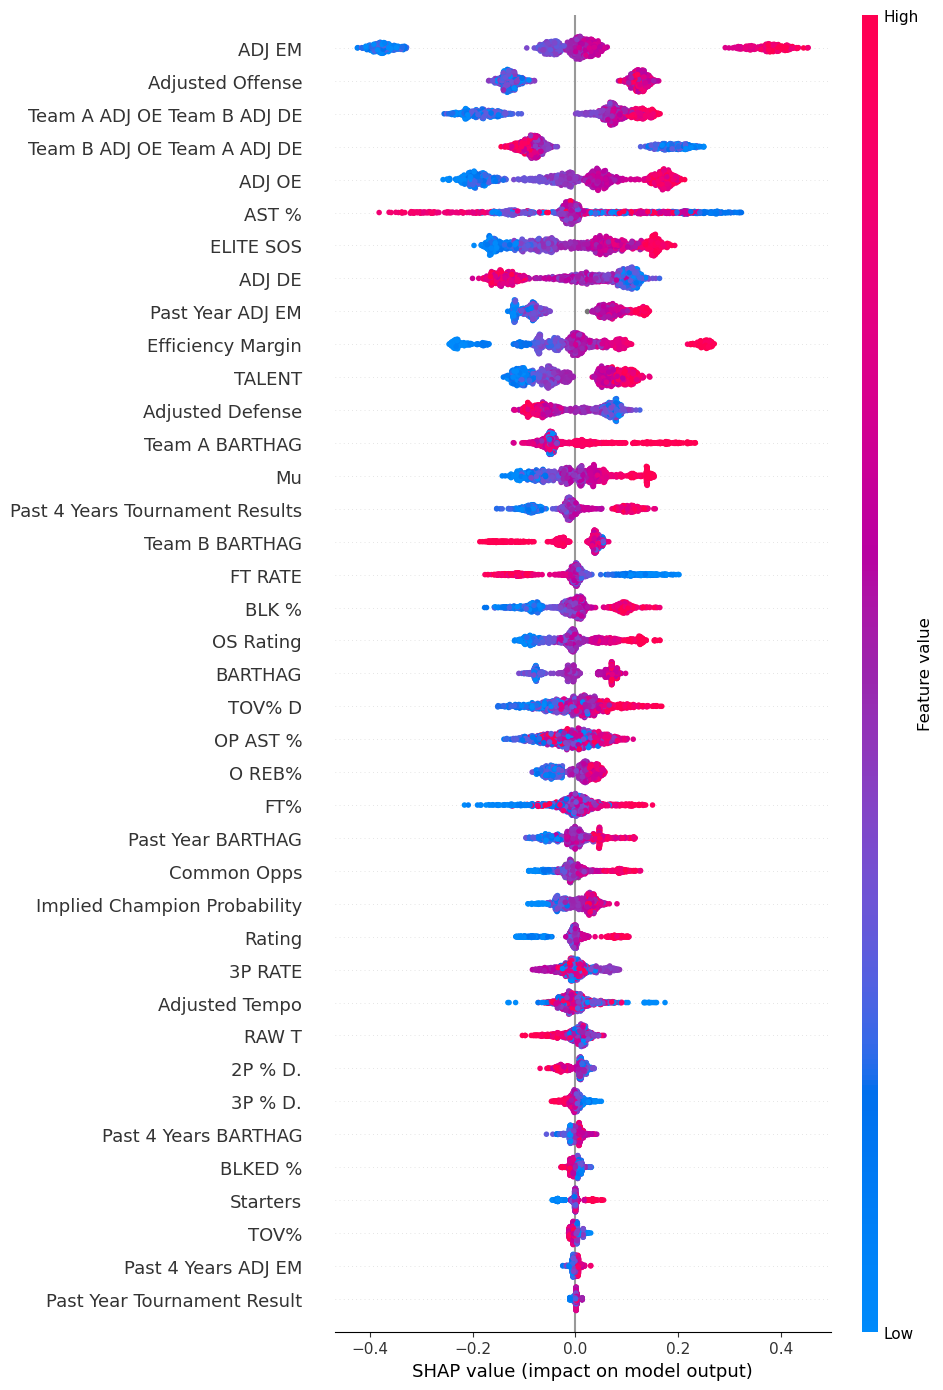

In [28]:
shap.plots.beeswarm(shap_values, max_display=None)

In [29]:
df_feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': mod.feature_importances_,
}).sort_values(['Importance'], ascending=False, ignore_index=True)

df_feature_importance

,Feature,Importance
0,AST %,81
1,FT%,49
2,Adjusted Tempo,49
3,OP AST %,48
4,TOV% D,36
5,ADJ DE,26
6,RAW T,25
7,Team A BARTHAG,21
8,FT RATE,20
9,ELITE SOS,20


### Save

In [ ]:
# import pickle

# with open('../data/models/mens/2025_03_15_model.pkl', 'wb') as f:
#     pickle.dump(mod, f)

# df_mod.to_parquet('../data/models/mens/2025_03_15_data.parquet')

# 'Done'

'Done'